# Reinforcement learning for Event Selection in particle physics

The core idea is to model a real-time particle event selection at the LHC (Large Hadron Collider), CERN as a **Markov Decision Process**.

## Configuration

This cell sets up the simulation environment, including event rates, pileup behavior, reward settings, and Q-learning hyperparameters. It defines how the agents are trained and how detector conditions evolve over each episode to mimic realistic LHC operation.

In [ ]:

EVENTS_PER_EPISODE = 1000     # collisions per episode
STORAGE_BUDGET = 100      # max accepts per episode (10% accept rate)


SIGNAL_RATE_MEAN = 0.001  # average signal rate (0.1% of events - an assumption I am currently using))
SIGNAL_RATE_STD = 0.0002 # variability in signal rate across episodes

PILEUP_START = 20       # mean pileup at start of episode
PILEUP_END = 50       # mean pileup at end of episode

'''
Reward r(s,a):
Accept signal → +R_SIG         reward true positive
Miss signal → -R_MISS        penalise false negative (irreplaceable!)
Accept background  → -R_BKG         penalise wasting storage
Reject background →  0             correct, costs nothing
Over budget → -R_OVERBUDGET  extra penalty for exceeding storage limit
'''

R_SIG = 10.0
R_MISS = 15.0   # missing signal is worse than a false positive
R_BKG =  1.0
R_OVERBUDGET =  5.0

# State
N_SCORE_BINS = 10    # for tabular agent
N_BUDGET_BINS = 10    # for tabular agent
N_FEATURES = 6     # for linear agent: [pt, met, n_jets, m_inv, pileup, budget_frac]
                     # note: LinearSARSA appends a bias term internally → 7 weights total

# Common Q-learning hyperparameters
GAMMA = 0.99   # discount factor
EPS_START = 1.0    # initial exploration rate
EPS_END = 0.05   # minimum exploration rate
EPS_DECAY = 0.995  # per-episode multiplicative decay
N_EPISODES = 2000

# Tabular Q-learning
ALPHA= 0.1    # learning rate

# Linear SARSA
ALPHA_LINEAR = 0.002   

print("Configuration loaded.")


Configuration loaded.



# LHC Trigger Environment

This cell defines a custom Gymnasium environment that simulates the real-time event selection problem in the LHC trigger system. 
This environment models the LHC trigger system as a discrete-time Markov Decision Process (MDP), where each step corresponds to a proton-proton collision event. The agent must decide whether to accept or reject events in real time while staying within a fixed storage budget.

- **Physics-inspired correlated features**: four raw features (pT, MET, n_jets, m_inv) with realistic distributions instead of a single abstract score
- **Dual observation modes**: `'discrete'` for tabular agent, `'continuous'` for linear agent — same environment serves both


In [2]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces


class LHCTriggerEnv(gym.Env):
    def __init__(self, obs_mode="discrete"):
        super().__init__()
        assert obs_mode in ("discrete", "continuous")
        self.obs_mode = obs_mode

        if obs_mode == "discrete":
            self.observation_space = spaces.MultiDiscrete([N_SCORE_BINS, N_BUDGET_BINS])
        else:
            self.observation_space = spaces.Box(
                low=0.0, high=1.0, shape=(N_FEATURES,), dtype=np.float32
            )
        self.action_space = spaces.Discrete(2)   # 0=REJECT, 1=ACCEPT


    '''
    Pileup:
    Pileup is the average number of simultaneous collisions per event, which degrades feature quality. 
    I have modeled it as increasing linearly across the episode, adding correlated noise to features.
    '''

    def _current_pileup_mean(self):
        frac = self._step / max(EVENTS_PER_EPISODE - 1, 1)
        return PILEUP_START + frac * (PILEUP_END - PILEUP_START)

   
    '''
    Event generation:
    Each event has 4 raw features (pT, MET, n_jets, m_inv).
    It returns :
        raw_features : np.ndarray shape (4,) — [pT, MET, n_jets, m_inv]
        is_signal    : bool
    '''

    def _new_event(self):
        is_signal = self.np_random.random() < self._signal_rate

        mu_pu = self._current_pileup_mean()

        pu_shared = self.np_random.normal(0, mu_pu * 0.003)
        pu_individual = self.np_random.normal(0, mu_pu * 0.002, size=4)
        pu_noise = pu_shared + pu_individual

        if is_signal:
            # Signal events have higher pT and MET, more jets, and m_inv around 125 GeV (Higgs mass).
            pt = self.np_random.normal(80, 25)
            met= self.np_random.normal(45, 18)
            njets = float(self.np_random.poisson(3))
            minv = self.np_random.normal(125, 4)
        else:
            # Background events have lower pT and MET, fewer jets, and a broad m_inv distribution.
            pt = self.np_random.exponential(28)
            met = self.np_random.exponential(12)
            njets = float(self.np_random.poisson(1.2))
            minv = self.np_random.uniform(20, 200)

        raw = np.array([pt, met, njets, minv], dtype=np.float64) + pu_noise
        return raw, is_signal

    '''
    Feature processing:
    Normalisation:
    Raw features are normalised to [0, 1].
    '''
    def _normalise(self, raw):
        return np.clip(
            np.array([raw[0]/200.0, raw[1]/100.0, raw[2]/10.0, raw[3]/300.0],
                     dtype=np.float32),
            0.0, 1.0
        )

    def _composite_score(self, norm):

        """
        Scalar signal quality score: weighted sum of normalised features.
        pT and MET are mostly discriminators.
        """
        return float(np.clip(np.dot([0.35, 0.30, 0.20, 0.15], norm), 0, 1))

    '''
    Observation:
    The observation returned to the agent depends on the mode:
    - Discrete mode: (score_bin, budget_bin) for tabular Q-learning.
    - Continuous mode: [pt_norm, met_norm, njets_norm, minv_norm'''

    def _get_obs(self):
        norm = self._normalise(self._raw_features)
        score = self._composite_score(norm)
        budget_frac = max(0.0, (STORAGE_BUDGET - self._accepted) / STORAGE_BUDGET)

        if self.obs_mode == "discrete":
            score_bin = min(int(score       * N_SCORE_BINS),  N_SCORE_BINS  - 1)
            budget_bin = min(int(budget_frac * N_BUDGET_BINS), N_BUDGET_BINS - 1)
            return np.array([score_bin, budget_bin], dtype=np.int64)
        else:
            mu_pu = self._current_pileup_mean()
            return np.array([
                norm[0],                              # pT (normalised)
                norm[1],                              # MET (normalised)
                norm[2],                              # n_jets (normalised)
                norm[3],                              # m_inv (normalised)
                np.clip(mu_pu / PILEUP_END, 0, 1),   # pileup progress
                budget_frac,                          # storage remaining
            ], dtype=np.float32)

    '''
    Reset the environment.
    '''

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self._step = 0
        self._accepted = 0
        self._sig_total = 0
        self._sig_caught = 0

        # Non-stationary: new signal rate each episode
        self._signal_rate = float(np.clip(
            self.np_random.normal(SIGNAL_RATE_MEAN, SIGNAL_RATE_STD),
            0.0005, 0.003
        ))

        self._raw_features, self._is_signal = self._new_event()
        self._sig_total += int(self._is_signal)
        return self._get_obs(), {}

    def step(self, action):
        over_budget = self._accepted >= STORAGE_BUDGET

        # Reward function
        if action == 1:   # ACCEPT
            if over_budget:
                reward = -R_OVERBUDGET
            else:
                reward = R_SIG if self._is_signal else -R_BKG
                self._accepted += 1
        else:             # REJECT
            reward = -R_MISS if self._is_signal else 0.0

        if action == 1 and self._is_signal and not over_budget:
            self._sig_caught += 1

        self._step += 1
        terminated = self._step >= EVENTS_PER_EPISODE

        self._raw_features, self._is_signal = self._new_event()
        self._sig_total += int(self._is_signal)

        info = {}
        if terminated:
            info = {
                "signal_efficiency": self._sig_caught / max(1, self._sig_total),
                "bkg_accepted": self._accepted - self._sig_caught,
                "total_accepted": self._accepted,
                "signal_rate": self._signal_rate,
            }
        return self._get_obs(), reward, terminated, False, info


# Testing the environment
print("Discrete mode (for tabular agent)")
env_d = LHCTriggerEnv(obs_mode="discrete")
obs, _ = env_d.reset(seed=0)
print(f"Obs space : {env_d.observation_space}")
print(f"Sample obs: {obs}  (score_bin, budget_bin)")

print("\nContinuous mode (for linear agent)")
env_c = LHCTriggerEnv(obs_mode="continuous")
obs, _ = env_c.reset(seed=0)
print(f"Obs space : {env_c.observation_space}")
print(f"Sample obs: {np.round(obs, 3)}")
print(f"Features  : [pT_norm, MET_norm, njets_norm, minv_norm, pileup_frac, budget_frac]")


Discrete mode (for tabular agent)
Obs space : MultiDiscrete([10 10])
Sample obs: [2 9]  (score_bin, budget_bin)

Continuous mode (for linear agent)
Obs space : Box(0.0, 1.0, (6,), float32)
Sample obs: [0.106 0.338 0.205 0.581 0.4   1.   ]
Features  : [pT_norm, MET_norm, njets_norm, minv_norm, pileup_frac, budget_frac]


## Reinforcement Learning Agents

Two reinforcement learning agents are implemented and compared in this project. Both use the same ε-greedy exploration strategy (during training, the agent occasionally selects random actions to explore unfamiliar states, while gradually shifting toward exploitation of the learned policy as ε decays over time), but differ in how they represent and learn the value function (Q(s,a)).


### Agent 1 — Tabular Q-learning

The tabular agent stores a separate Q-value for every discrete state-action pair using a lookup table indexed by `(score_bin, budget_bin)`. With 10 score bins, 10 budget bins, and 2 actions, the full table contains 200 learnable values.

This approach is simple and interpretable, but it only learns about states it has explicitly visited.

#### Q-learning update rule

The tabular agent updates its value estimates using:

$$
Q(s,a) \leftarrow Q(s,a) + \alpha \Big[ r + \gamma \max_{a'} Q(s',a') - Q(s,a) \Big]
$$

where:

$$
\alpha = \text{learning rate}
$$

$$
\gamma = \text{discount factor}
$$

$$
r = \text{immediate reward}
$$

$$
\max_{a'} Q(s',a') = \text{best estimated value of the next state}
$$


### Agent 2 — Linear SARSA

The second agent uses linear function approximation together with the SARSA update rule. Instead of storing a lookup table, the action-value function is represented as:

$$
Q(s,a;\mathbf{w}_a) = \mathbf{w}_a^\top \phi(s)
$$

where ($\phi(s)$) is a feature vector constructed from the event observables:

$$
\phi(s) =
[p_T, MET, n_{\text{jets}}, m_{\text{inv}}, \text{pileup}, \text{budget}, p_T \cdot MET, p_T \cdot \text{budget}, MET \cdot \text{budget}, 1]
$$

The first six entries are normalized base features, followed by nonlinear interaction terms that help the agent capture correlations between physical observables and resource constraints.

The appended constant term (1) acts as a learnable bias feature, allowing the policy to shift independently of the input magnitudes.

Unlike Q-learning, SARSA is an **on-policy** method. The update uses the action actually selected in the next state rather than the maximum estimated future action value. This generally leads to more stable learning when combined with function approximation.

#### SARSA update rule

The temporal-difference error is:

$$
\delta = r + \gamma Q(s', a'; \mathbf{W}) - Q(s,a;\mathbf{W})
$$

where (a') is the next action chosen by the current ε-greedy policy.

The weights are then updated using the semi-gradient SARSA rule:

$$
\mathbf{w}_a \leftarrow \mathbf{w}_a + \alpha , \delta , \phi(s)
$$

This approach allows learning to generalize across similar events, making the linear SARSA agent more scalable and better suited to continuous observation spaces than the tabular approach.


(To be explored: A DQN model)


In [ ]:

# Shared ε-greedy 

class EpsilonGreedyMixin:
    """
    Shared exploration logic for both agents.
    """
    def _init_epsilon(self):
        self.epsilon = EPS_START

    def decay_epsilon(self):
        self.epsilon = max(EPS_END, self.epsilon * EPS_DECAY)

    def _epsilon_greedy(self, q_values, greedy=False):
        if not greedy and np.random.random() < self.epsilon:
            return np.random.randint(len(q_values))
        return int(np.argmax(q_values))


# Agent 1 — Tabular Q-learning

class QLearningAgent(EpsilonGreedyMixin):

    def __init__(self):
        self.Q = np.zeros((N_SCORE_BINS, N_BUDGET_BINS, 2))
        self._init_epsilon()

    def get_action(self, obs, greedy=False):
        return self._epsilon_greedy(self.Q[obs[0], obs[1]], greedy)

    def update(self, obs, action, reward, next_obs, done):

        current = self.Q[obs[0], obs[1], action]

        target = (
            reward if done
            else reward + GAMMA * np.max(self.Q[next_obs[0], next_obs[1]])
        )

        td_error = target - current

        self.Q[obs[0], obs[1], action] += ALPHA * td_error

        return td_error

    def policy_matrix(self):
        return np.argmax(self.Q, axis=-1)

    def q_advantage(self):
        return self.Q[:, :, 1] - self.Q[:, :, 0]



# Agent 2 — Stable Linear SARSA Agent

class LinearSARSA(EpsilonGreedyMixin):
    def __init__(self, n_actions=2):

        self.n_actions = n_actions

        # 6 base + 3 interactions + 1 bias
        self.n_features = 10

        rng = np.random.default_rng(42)

        self.W = rng.normal(
            loc=0.0,
            scale=0.001,
            size=(n_actions, self.n_features)
        )

        # Slight positive prior toward ACCEPT
        self.W[1, -1] = 0.01

        self.alpha = ALPHA_LINEAR

        self._init_epsilon()

        # Feature scaling constants
        self.feature_max = np.array([
            1.0,  # pT already normalized in env
            1.0,  # MET
            1.0,  # n_jets
            1.0,  # m_inv
            1.0,  # pileup
            1.0   # budget_frac
        ], dtype=np.float32)

  

    def _normalize(self, obs):

        obs = np.asarray(obs, dtype=np.float32)

        return obs / self.feature_max

    def _features(self, obs):
        pT, MET, n_jets, m_inv, pileup, budget = self._normalize(obs)

        phi = np.array([

            # Base features
            pT,
            MET,
            n_jets,
            m_inv,
            pileup,
            budget,

            # Nonlinear interactions
            pT * MET,
            pT * budget,
            MET * budget,

            # Bias
            1.0

        ], dtype=np.float32)

        return phi

    def _q_values(self, obs):

        phi = self._features(obs)

        return self.W @ phi


    def get_action(self, obs, greedy=False):

        q_values = self._q_values(obs)

        return self._epsilon_greedy(q_values, greedy)

    # SARSA update
    def update(self, obs, action, reward, next_obs, done):

        phi = self._features(obs)

        current_q = float(self.W[action] @ phi)

        if done:

            target = reward

        else:

            next_action = self.get_action(next_obs)

            next_q = float(self._q_values(next_obs)[next_action])

            target = reward + GAMMA * next_q

        td_error = target - current_q

        # Stable semi-gradient update
        self.W[action] += self.alpha * td_error * phi

        return td_error


    def feature_importance(self):

        names = [
            "pT",
            "MET",
            "n_jets",
            "m_inv",
            "pileup",
            "budget",
            "pT*MET",
            "pT*budget",
            "MET*budget",
            "bias"
        ]

        diff = self.W[1] - self.W[0]

        print("\nLinear agent — feature weights (ACCEPT − REJECT):")

        for name, val in sorted(
            zip(names, diff),
            key=lambda x: -abs(x[1])
        ):
            print(f"{name:<15} {val:+.4f}")


## Training

Both agents are trained for `N_EPISODES` episodes on their respective environment modes.
The training loop is similar for both, only the environment mode and agent class differ.


In [4]:
import os
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams["figure.dpi"] = 120
os.makedirs("results", exist_ok=True)


def run_training(agent, env, label):
    rewards, sig_effs, bkg_accs = [], [], []

    print(f"\nTraining {label} for {N_EPISODES} episodes …")
    print(f"{'Episode':>8}  {'Reward':>9}  {'SigEff':>8}  {'BkgAcc':>8}  {'ε':>7}")
    print("-" * 50)

    for ep in range(1, N_EPISODES + 1):
        obs, _  = env.reset()
        total_reward = 0.0

        while True:
            action = agent.get_action(obs)
            next_obs, reward, done, _, info = env.step(action)
            agent.update(obs, action, reward, next_obs, done)
            total_reward += reward
            obs = next_obs
            if done:
                break

        agent.decay_epsilon()
        rewards.append(total_reward)
        sig_effs.append(info.get("signal_efficiency", 0))
        bkg_accs.append(info.get("bkg_accepted", 0))

        if ep % 400 == 0 or ep == 1:
            print(f"{ep:>8}  {total_reward:>9.1f}  {sig_effs[-1]:>8.3f}"
                  f"  {bkg_accs[-1]:>8.0f}  {agent.epsilon:>7.4f}")

    print(f"Training complete.")
    return rewards, sig_effs, bkg_accs


# Train tabular agent
tab_agent = QLearningAgent()
env_d = LHCTriggerEnv(obs_mode="discrete")
tab_rewards, tab_sig, tab_bkg = run_training(tab_agent, env_d, "Tabular Q-learning")

# Train linear agent
lin_agent = LinearSARSA()
env_c = LHCTriggerEnv(obs_mode="continuous")
lin_rewards, lin_sig, lin_bkg = run_training(lin_agent, env_c, "Linear SARSA")

np.save("results/q_table.npy",   tab_agent.Q)
np.save("results/lin_weights.npy", lin_agent.W)
print("\nWeights saved.")



Training Tabular Q-learning for 2000 episodes …
 Episode     Reward    SigEff    BkgAcc        ε
--------------------------------------------------
       1    -2075.0     0.000       100   0.9950
     400      -94.0     0.000        94   0.1347
     800      -49.0     1.000        59   0.0500
    1200      -41.0     0.500        36   0.0500
    1600      -35.0     1.000        65   0.0500
    2000      -49.0     1.000        59   0.0500
Training complete.

Training Linear SARSA for 2000 episodes …
 Episode     Reward    SigEff    BkgAcc        ε
--------------------------------------------------
       1    -2134.0     1.000        99   0.9950
     400      -69.0     1.000        79   0.1347
     800      -38.0     0.000        23   0.0500
    1200      -27.0     0.500        22   0.0500
    1600      -50.0     0.000        35   0.0500
    2000      -23.0     0.000        23   0.0500
Training complete.

Weights saved.


## Evaluation

Four-way comparison:
1. **Random policy** — lower bound: accept with probability 0.5
2. **Fixed threshold (τ = 0.55)** — accepts any event with score ≥ 0.55, no budget awareness
3. **Tabular Q-learning** — trained greedy policy on discrete state
4. **Linear SARSA** — on-policy TD control with linear function approximation; learns Q-values for the policy being followed, using continuous features




In [5]:
def evaluate_tabular(agent, n_episodes=200):
    env = LHCTriggerEnv(obs_mode="discrete")
    results = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        while True:
            action = agent.get_action(obs, greedy=True)
            obs, _, done, _, info = env.step(action)
            if done:
                results.append(info)
                break
    return results


def evaluate_linear(agent, n_episodes=200):
    env = LHCTriggerEnv(obs_mode="continuous")
    results = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        while True:
            action = agent.get_action(obs, greedy=True)
            obs, _, done, _, info = env.step(action)
            if done:
                results.append(info)
                break
    return results


def evaluate_threshold(threshold=0.55, n_episodes=200):
    env = LHCTriggerEnv(obs_mode="continuous")
    results = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        while True:
            score = env._composite_score(env._normalise(env._raw_features))
            action = 1 if (score >= threshold and env._accepted < STORAGE_BUDGET) else 0
            obs, _, done, _, info = env.step(action)
            if done:
                results.append(info)
                break
    return results


def evaluate_random(n_episodes=200):
    env = LHCTriggerEnv(obs_mode="discrete")
    results = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        while True:
            action = np.random.randint(2)
            obs, _, done, _, info = env.step(action)
            if done:
                results.append(info)
                break
    return results


def summarise(results, label):
    sig = np.mean([r["signal_efficiency"] for r in results])
    sig_std = np.std([r["signal_efficiency"] for r in results])
    bkg = np.mean([r["bkg_accepted"] for r in results])
    bkg_std = np.std([r["bkg_accepted"] for r in results])
    tot = np.mean([r["total_accepted"] for r in results])
    print(f"{label:<28}  sig_eff={sig:.3f}±{sig_std:.3f}  bkg={bkg:.1f}±{bkg_std:.1f}  total={tot:.1f}")
    return sig, sig_std, bkg, bkg_std, tot


print("Evaluating all methods over 200 episodes …\n")
tab_results = evaluate_tabular(tab_agent)
lin_results = evaluate_linear(lin_agent)
bl_results = evaluate_threshold(threshold=0.55)
rand_results = evaluate_random()

print(f"{'Method':<28}  {'sig_eff (mean±std)':>20}  {'bkg_acc':>10}  {'total':>8}")
print("-" * 72)
tab_sig_m, tab_sig_s, tab_bkg_m, tab_bkg_s,  _ = summarise(tab_results,  "Tabular Q-learning")
lin_sig_m, lin_sig_s,  lin_bkg_m, lin_bkg_s,  _ = summarise(lin_results,  "Linear SARSA")
bl_sig_m, bl_sig_s, bl_bkg_m, bl_bkg_s,   _ = summarise(bl_results,   "Fixed threshold (τ=0.55)")
rnd_sig_m, rnd_sig_s, rnd_bkg_m, rnd_bkg_s,  _ = summarise(rand_results, "Random policy")


Evaluating all methods over 200 episodes …

Method                          sig_eff (mean±std)     bkg_acc     total
------------------------------------------------------------------------
Tabular Q-learning            sig_eff=0.353±0.450  bkg=15.6±2.6  total=16.1
Linear SARSA                  sig_eff=0.107±0.276  bkg=1.3±1.2  total=1.4
Fixed threshold (τ=0.55)      sig_eff=0.025±0.148  bkg=0.1±0.4  total=0.2
Random policy                 sig_eff=0.075±0.236  bkg=99.9±0.3  total=100.0


## Plots

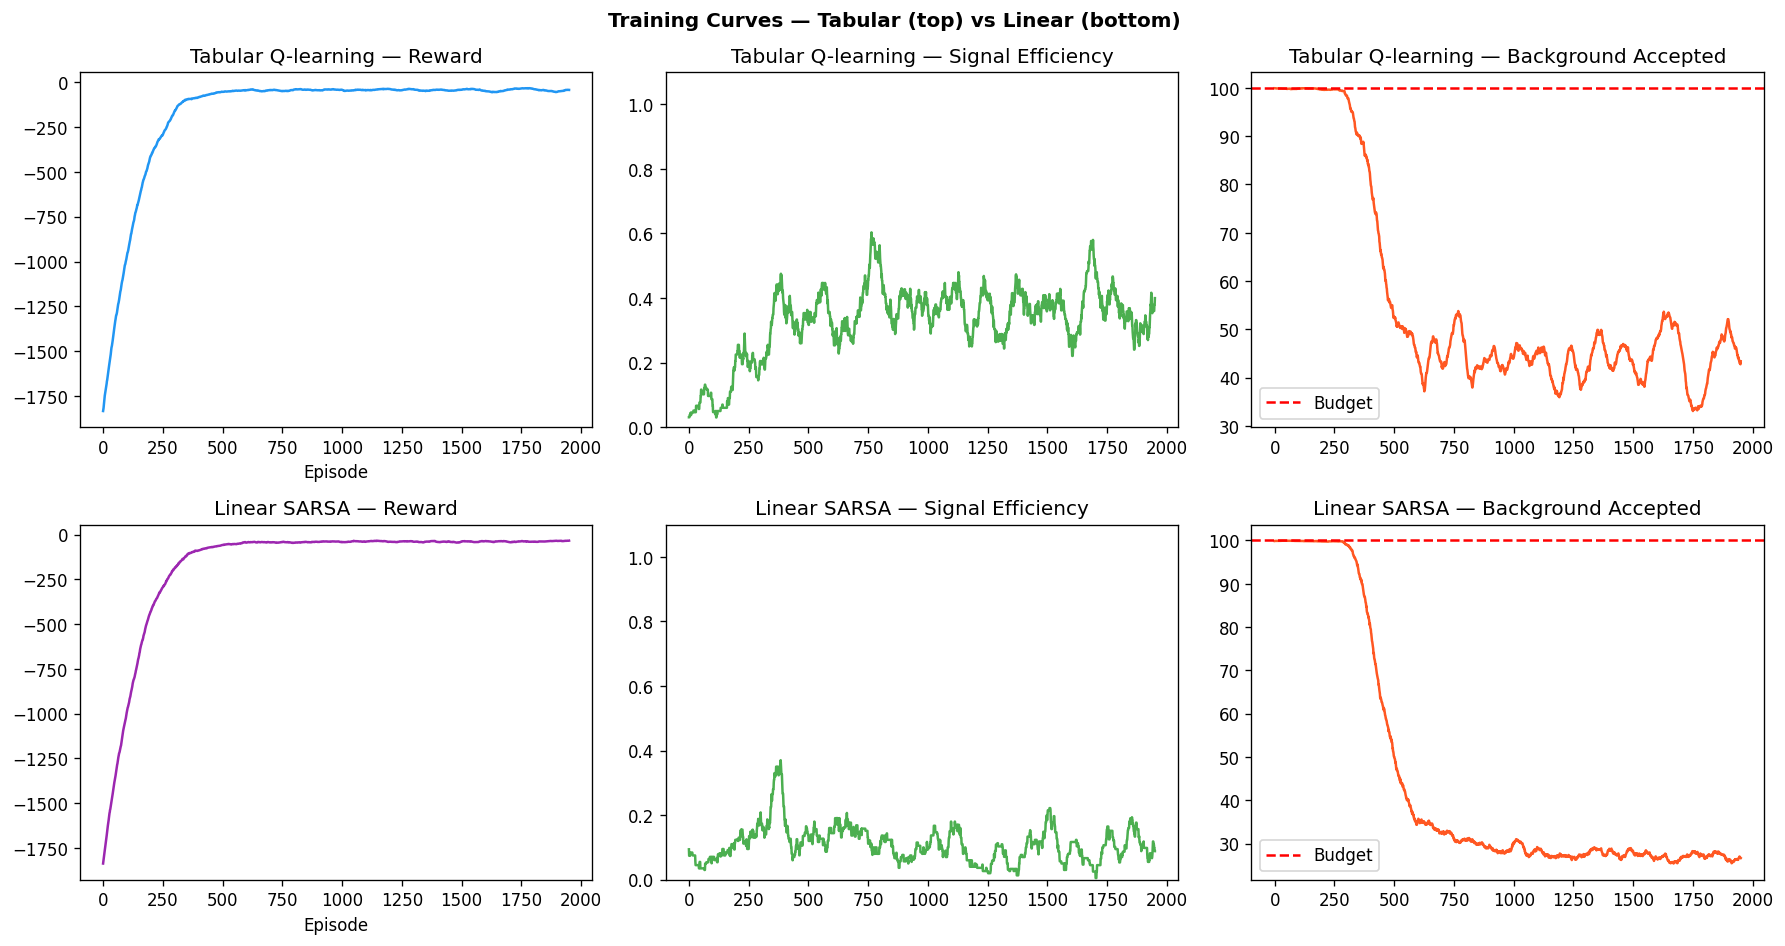

Saved: results/training_curves.png


In [6]:
def smooth(x, w=50):
    return np.convolve(x, np.ones(w) / w, mode="valid")


fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Training Curves — Tabular (top) vs Linear (bottom)", fontweight="bold")

for row, (rewards, sig_effs, bkg_accs, label, colour) in enumerate([
    (tab_rewards, tab_sig, tab_bkg, "Tabular Q-learning", "#2196F3"),
    (lin_rewards, lin_sig, lin_bkg, "Linear SARSA",  "#9C27B0"),
]):
    axes[row,0].plot(smooth(rewards),  color=colour)
    axes[row,0].set_title(f"{label} — Reward")
    axes[row,0].set_xlabel("Episode")

    axes[row,1].plot(smooth(sig_effs), color="#4CAF50")
    axes[row,1].set_title(f"{label} — Signal Efficiency")
    axes[row,1].set_ylim(0, 1.1)

    axes[row,2].plot(smooth(bkg_accs), color="#FF5722")
    axes[row,2].axhline(STORAGE_BUDGET, color="red", linestyle="--", label="Budget")
    axes[row,2].set_title(f"{label} — Background Accepted")
    axes[row,2].legend()

plt.tight_layout()
plt.savefig("results/training_curves.png")
plt.show()
print("Saved: results/training_curves.png")


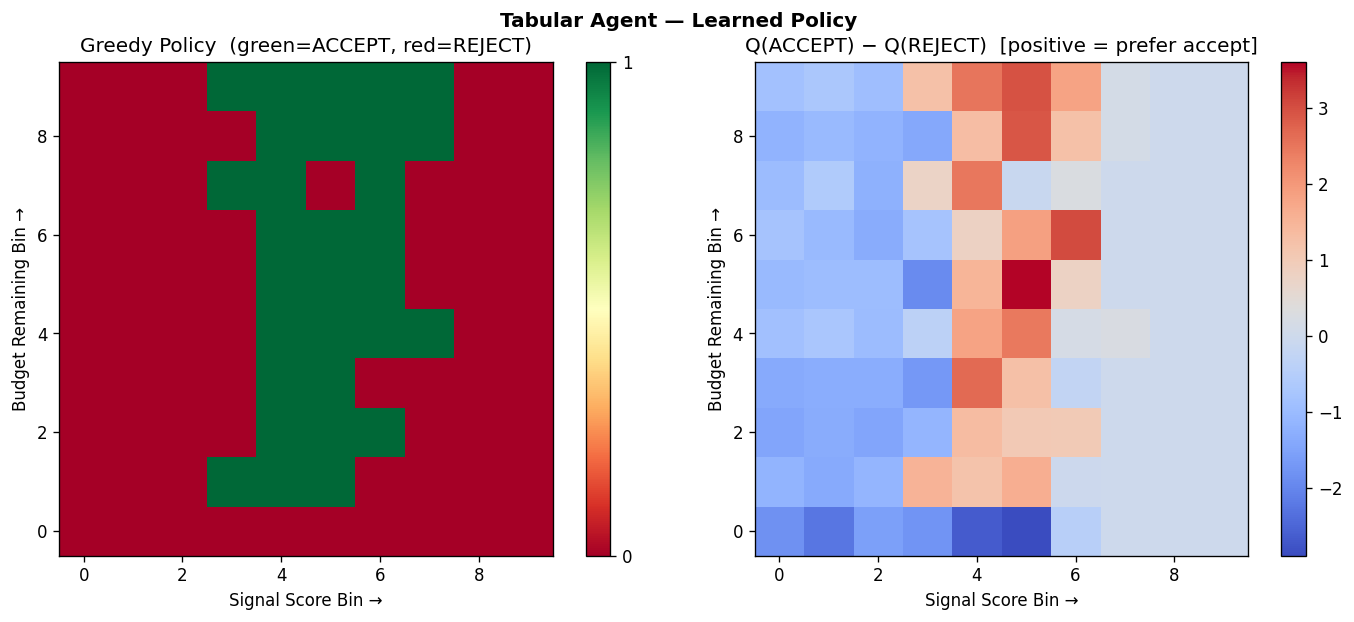

Saved: results/policy_heatmap.png


In [7]:
# Tabular policy heatmap
policy = tab_agent.policy_matrix()   # shape (score_bins, budget_bins)
qdiff  = tab_agent.q_advantage()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Tabular Agent — Learned Policy", fontweight="bold")

im = axes[0].imshow(policy.T, origin="lower", cmap="RdYlGn", vmin=0, vmax=1)
axes[0].set_title("Greedy Policy  (green=ACCEPT, red=REJECT)")
axes[0].set_xlabel("Signal Score Bin →")
axes[0].set_ylabel("Budget Remaining Bin →")
plt.colorbar(im, ax=axes[0], ticks=[0, 1])

im2 = axes[1].imshow(qdiff.T, origin="lower", cmap="coolwarm")
axes[1].set_title("Q(ACCEPT) − Q(REJECT)  [positive = prefer accept]")
axes[1].set_xlabel("Signal Score Bin →")
axes[1].set_ylabel("Budget Remaining Bin →")
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.savefig("results/policy_heatmap.png")
plt.show()
print("Saved: results/policy_heatmap.png")


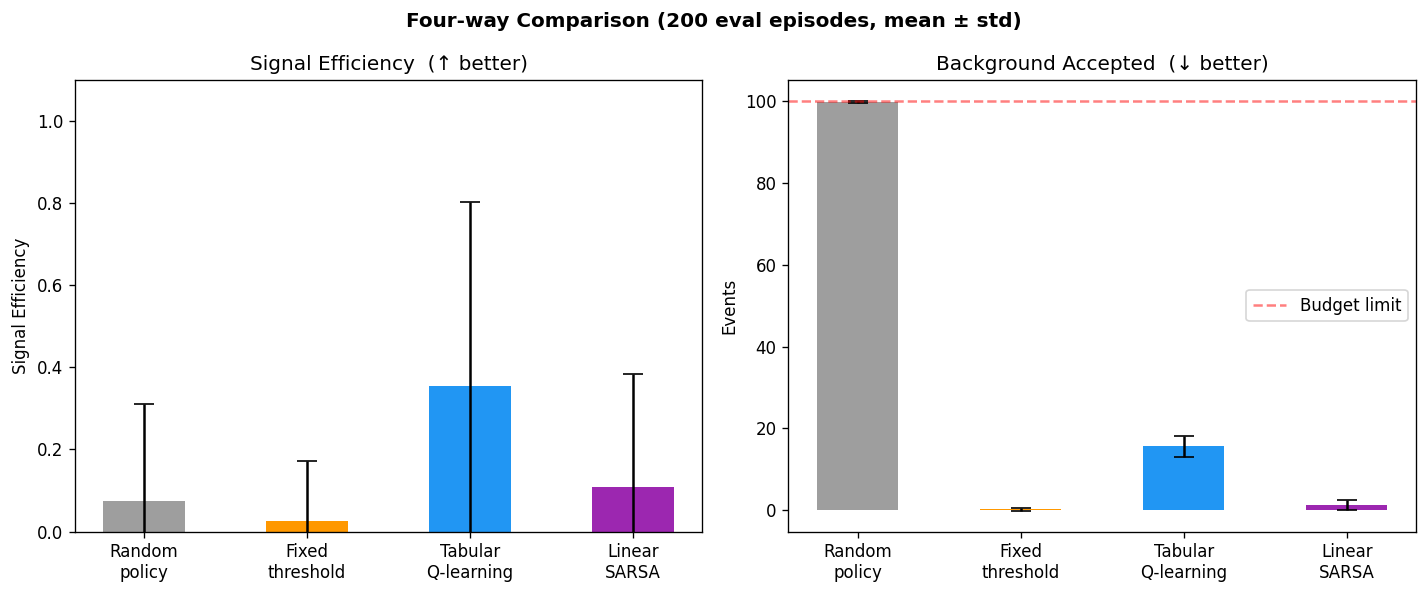

Saved: results/comparison.png


In [8]:
# Four-way comparison bar chart
methods     = ["Random\npolicy", "Fixed\nthreshold", "Tabular\nQ-learning", "Linear\nSARSA"]
sig_means   = [rnd_sig_m,  bl_sig_m,  tab_sig_m,  lin_sig_m]
sig_stds    = [rnd_sig_s,  bl_sig_s,  tab_sig_s,  lin_sig_s]
bkg_means   = [rnd_bkg_m,  bl_bkg_m,  tab_bkg_m,  lin_bkg_m]
bkg_stds    = [rnd_bkg_s,  bl_bkg_s,  tab_bkg_s,  lin_bkg_s]
colours     = ["#9E9E9E",  "#FF9800",  "#2196F3",  "#9C27B0"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Four-way Comparison (200 eval episodes, mean ± std)", fontweight="bold")

axes[0].bar(methods, sig_means, yerr=sig_stds, color=colours, capsize=6, width=0.5)
axes[0].set_title("Signal Efficiency  (↑ better)")
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel("Signal Efficiency")

axes[1].bar(methods, bkg_means, yerr=bkg_stds, color=colours, capsize=6, width=0.5)
axes[1].axhline(STORAGE_BUDGET, color="red", linestyle="--", alpha=0.5, label="Budget limit")
axes[1].set_title("Background Accepted  (↓ better)")
axes[1].set_ylabel("Events")
axes[1].legend()

plt.tight_layout()
plt.savefig("results/comparison.png")
plt.show()
print("Saved: results/comparison.png")


## Policy Evaluation and Inspection

### Tabular agent: Q-table readout
Because the Q-function is a lookup table, we can directly read what the agent learned for any state.

### Linear agent: feature weights
Because the Q-function is linear, the weight vector directly shows us which features drive decisions.


In [9]:
# Tabular agent: Q-table readout
print("Tabular agent — Q[ACCEPT] − Q[REJECT] for selected states:")
print("  Positive → prefer ACCEPT,  Negative → prefer REJECT")
print()
print(f"  {'score_bin':>10}  {'budget_bin':>10}  {'Q_diff':>10}  {'decision':>10}")
print("  " + "-" * 46)
for s in range(N_SCORE_BINS):
    for b in [0, 4, 9]:   # low / mid / high budget remaining
        diff     = tab_agent.Q[s, b, 1] - tab_agent.Q[s, b, 0]
        decision = "ACCEPT" if diff > 0 else "REJECT"
        print(f"  {s:>10}  {b:>10}  {diff:>+10.3f}  {decision:>10}")

# Linear agent: feature importance
lin_agent.feature_importance()


Tabular agent — Q[ACCEPT] − Q[REJECT] for selected states:
  Positive → prefer ACCEPT,  Negative → prefer REJECT

   score_bin  budget_bin      Q_diff    decision
  ----------------------------------------------
           0           0      -1.808      REJECT
           0           4      -0.858      REJECT
           0           9      -0.853      REJECT
           1           0      -2.250      REJECT
           1           4      -0.719      REJECT
           1           9      -0.688      REJECT
           2           0      -1.553      REJECT
           2           4      -0.969      REJECT
           2           9      -0.921      REJECT
           3           0      -1.761      REJECT
           3           4      -0.352      REJECT
           3           9      +1.242      ACCEPT
           4           0      -2.633      REJECT
           4           4      +1.819      ACCEPT
           4           9      +2.499      ACCEPT
           5           0      -2.886      REJECT
    